# Pension Model Results Analysis

This notebook analyzes the run selected by `RUN_TAG` in `Results/Runs/`. It leads with stochastic risk metrics (asset-exhaustion probabilities, threshold risk, distribution fans), then aggregate dynamics, per-plan detail, and finally baseline/descriptive context and validation. Figures are displayed in the notebook and are not saved to disk.

A note on simulation structure: as of 2026-06-10, the Python asset simulation uses **common market shocks** — simulation column *n* is the same market history for every plan — so cross-plan aggregate distributions (fans, tail percentiles) are meaningful. If the loaded outputs predate this change (or are R outputs with independent per-plan draws), aggregate bands understate risk; the load cell below checks the flag.

In [5]:
from pathlib import Path
import sys

# results_analysis.py is co-located with this notebook
_here = Path.cwd().resolve()
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import results_analysis as ra

ROOT = ra.find_project_root()
RUN_TAG = "062026"        # folder name under Results/Runs; change this for another run
RESULT_SOURCE = "auto"    # "auto" detects from the run folder; or set "rdata" (R) / "parquet" (Python)
GRAPH_YEARS = 15          # horizon for forecast-style figures; risk metrics use the full projection
RUN_DIR = ra.run_dir(ROOT, RUN_TAG)
if RESULT_SOURCE == "auto":
    RESULT_SOURCE = ra.detect_result_source(ROOT, RUN_TAG)
print(f"RESULT_SOURCE = {RESULT_SOURCE!r}")

plt.style.use("seaborn-v0_8-whitegrid")
print(ROOT)
print(RUN_DIR)

RESULT_SOURCE = 'parquet'
C:\Users\nicco\Massachusetts Institute of Technology\MIT Golub Center for Finance and Policy - Documents (1)\Research and Education\Projects\State and Local Pension\State Pension Model
C:\Users\nicco\Massachusetts Institute of Technology\MIT Golub Center for Finance and Policy - Documents (1)\Research and Education\Projects\State and Local Pension\State Pension Model\Results\Runs\062026


## Run Inventory

The first table counts deterministic A/L and asset-simulation statuses in the selected run manifest. The second table lists the plan-level manifest records, so missing or skipped outputs can be identified before interpreting the results.

In [6]:
manifest = ra.load_manifest(ROOT, RUN_TAG)
status_counts = manifest.groupby(["detal_status", "asset_status"]).size().rename("count").reset_index()
display(status_counts)
display(manifest.sort_values(["asset_status", "detal_status", "plan"]))

,detal_status,asset_status,count
0,valid,saved,37


,plan,detal_status,asset_status,skip_reason,detAL_file,asset_file,run_tag,num_sim,parquet_dir,timestamp,elapsed_s
0,AZ06,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:25:54,3.60
1,AZ127,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:25:57,3.67
2,CA10,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:01,3.68
3,CA111,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:05,3.64
4,CA144,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:08,3.69
5,CA43,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:12,3.78
6,CA97,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:16,3.71
7,CA98,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:19,3.75
8,DC20,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:23,3.82
9,FL26,valid,saved,NaN,C:\Users\nicco\Massachusetts Institute of Tech...,C:\Users\nicco\Massachusetts Institute of Tech...,62026,10000,C:\Users\nicco\Massachusetts Institute of Tech...,2026-06-10 13:26:27,3.77


## Select And Read Simulation Outputs

`RUN_TAG` selects the folder under `Results/Runs/`. `RESULT_SOURCE` sets the input format: `"auto"` (default) detects it from the run folder contents, or set `"rdata"` (R run outputs) / `"parquet"` (Python run outputs) explicitly. `SELECTED_PLANS = None` reads every plan in that run with an asset-simulation result; set it to a list such as `["CA10", "AZ06"]` for a faster subset.

For R result files (`RESULT_SOURCE = "rdata"`), the notebook creates clean `*_analysis.RData` companion files when needed. The cell also checks the common-market-shock flag saved with each plan's asset output: aggregate distribution bands later in the notebook are only meaningful when all plans share one shock matrix.

In [7]:
SELECTED_PLANS = None
# SELECTED_PLANS = ["CA10", "AZ06", "PA93"]

if RESULT_SOURCE == "rdata":
    ra.prepare_analysis_exports(ROOT, RUN_TAG, plans=SELECTED_PLANS, overwrite=False, progress=True)

results = ra.load_run_results(ROOT, RUN_TAG, plans=SELECTED_PLANS, progress=True, source=RESULT_SOURCE)
print(f"Using {len(results)} plans with asset simulations in the selected run.")

# Common-shock flag check (see header note)
_common = {p: str(r.scalars.get("common_market_shocks", "")).strip().lower() == "true"
           for p, r in results.items()}
if all(_common.values()):
    seeds = {str(r.scalars.get("market_seed", "")) for r in results.values()}
    print(f"All plans share common market shocks (market_seed = {sorted(seeds)}). Aggregate fans are valid.")
else:
    missing = sorted(p for p, ok in _common.items() if not ok)
    print(f"[warn] {len(missing)} plan(s) lack the common-shock flag: {missing}")
    print("[warn] Aggregate distribution bands will UNDERSTATE risk (independent draws cancel across plans).")

ppd = ra.load_ppd(ROOT)
print(f"PPD reference data: {ppd.shape[0]} rows")

analysis_inventory = pd.DataFrame(
    {
        "plan": plan,
        "ppid": result.ppid,
        "plan_year": result.plan_year,
        "n_years": result.n_years,
        "n_simulations": result.n_simulations,
        "file": str(result.file_path),
    }
    for plan, result in results.items()
)
display(analysis_inventory)

[1/37] loading AZ06
[2/37] loading AZ127
[3/37] loading CA10
[4/37] loading CA111
[5/37] loading CA144
[6/37] loading CA43
[7/37] loading CA97
[8/37] loading CA98
[9/37] loading DC20
[10/37] loading FL26
[11/37] loading GA27
[12/37] loading GA28
[13/37] loading IL32
[14/37] loading IL33
[15/37] loading IL34
[16/37] loading IN37
[17/37] loading LA130
[18/37] loading LA163
[19/37] loading LA44
[20/37] loading ME47
[21/37] loading MI53
[22/37] loading MO175
[23/37] loading ND82
[24/37] loading NJ71
[25/37] loading NJ73
[26/37] loading NM74
[27/37] loading NY78
[28/37] loading NY83
[29/37] loading OH88
[30/37] loading OK134
[31/37] loading OR91
[32/37] loading PA92
[33/37] loading PA93
[34/37] loading RI96
[35/37] loading SC100
[36/37] loading SC99
[37/37] loading TX108
Using 37 plans with asset simulations in the selected run.
All plans share common market shocks (market_seed = ['123']). Aggregate fans are valid.
PPD reference data: 5646 rows


,plan,ppid,plan_year,n_years,n_simulations,file
0,AZ06,6,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
1,AZ127,127,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
2,CA10,10,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
3,CA111,111,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
4,CA144,144,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
5,CA43,43,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
6,CA97,97,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
7,CA98,98,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
8,DC20,20,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...
9,FL26,26,2022,35,10000,C:\Users\nicco\Massachusetts Institute of Tech...


## Metric Construction

This code-only section builds the plan-level variables used throughout: official funded ratios, unfunded liabilities relative to payroll, contribution rates, active-to-retired ratios, first asset-exhaustion years per simulation path, aggregate per-path balance sheets, and FRED fetch helpers. `N_PROJ` is the usable projection length (the final placeholder year with zero AAL is dropped).

In [8]:
import json as _json
import os
import re
from urllib.parse import urlencode
from urllib.request import urlopen

MODEL_POPULATION_GROWTH = 0.01
N_PROJ = min(r.n_years for r in results.values()) - 1   # drop final placeholder year
BASE_YEAR = int(min(result.plan_year for result in results.values()))

TABLE1_METRICS = [
    ("Assets / liabilities", "assets_liabilities", "ActLiabilities_GASB"),
    ("Unfunded liabilities / payroll", "unfunded_liabilities_payroll", "payroll"),
    ("Total pension contributions / payroll", "total_pension_contributions_payroll", "payroll"),
    ("Active members / retired members", "active_retired_members", "retired_members"),
    ("Projected active member growth, 30 years", "projected_active_member_growth_30yr", "actives_tot"),
]


def finite_numeric(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.where(np.isfinite(values))


def num_col(frame, name):
    if name not in frame.columns:
        return pd.Series(np.nan, index=frame.index, dtype="float64")
    return finite_numeric(frame[name])


def safe_ratio(numerator, denominator):
    numerator = finite_numeric(numerator)
    denominator = finite_numeric(denominator)
    return (numerator / denominator).where(denominator > 0)


def first_available(frame, names):
    out = pd.Series(np.nan, index=frame.index, dtype="float64")
    for name in names:
        if name in frame.columns:
            out = out.fillna(pd.to_numeric(frame[name], errors="coerce"))
    return out


def add_core_metrics(frame, include_model_growth=True):
    data = frame.copy()
    data["assets_liabilities"] = safe_ratio(num_col(data, "ActAssets_GASB"), num_col(data, "ActLiabilities_GASB"))
    data["unfunded_liabilities"] = num_col(data, "ActLiabilities_GASB") - num_col(data, "ActAssets_GASB")
    data["unfunded_liabilities_payroll"] = safe_ratio(data["unfunded_liabilities"], num_col(data, "payroll"))
    data["total_pension_contributions_payroll"] = safe_ratio(num_col(data, "contrib_tot"), num_col(data, "payroll"))
    data["retired_members"] = first_available(data, ["beneficiaries_tot", "beneficiaries_ServiceRetirees"])
    data["active_retired_members"] = safe_ratio(num_col(data, "actives_tot"), data["retired_members"])
    if include_model_growth:
        data["projected_active_member_growth_30yr"] = (1 + MODEL_POPULATION_GROWTH) ** 30 - 1
    else:
        data["projected_active_member_growth_30yr"] = np.nan
    data["official_funded_ratio"] = data["assets_liabilities"]
    data["liability_billion"] = num_col(data, "ActLiabilities_GASB") / 1_000_000
    data["unfunded_liability_billion"] = data["unfunded_liabilities"] / 1_000_000
    data["contribution_rate"] = data["total_pension_contributions_payroll"]
    return data


def build_plan_metrics(results):
    rows = []
    for plan, result in sorted(results.items()):
        row = result.planinfo.iloc[0].to_dict() if result.planinfo is not None else {}
        row.update({
            "plan": plan,
            "ppid": result.ppid,
            "model_aal": result.scalars.get("Model_AAL"),
            "cafr_aal": result.scalars.get("CAFR_AAL"),
            "percent_difference": result.scalars.get("Percent_difference"),
            "n_simulations": result.n_simulations,
        })
        rows.append(row)
    data = add_core_metrics(pd.DataFrame(rows), include_model_growth=True)
    data["model_aal_billion"] = pd.to_numeric(data["model_aal"], errors="coerce") / 1_000_000_000
    data["cafr_aal_billion"] = pd.to_numeric(data["cafr_aal"], errors="coerce") / 1_000_000_000
    data["percent_difference"] = pd.to_numeric(data["percent_difference"], errors="coerce")
    return data


def weighted_mean_sd(values, weights):
    values = finite_numeric(values).to_numpy(dtype="float64")
    weights = finite_numeric(weights).to_numpy(dtype="float64")
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not mask.any():
        return np.nan, np.nan, 0
    values = values[mask]
    weights = weights[mask]
    mean = np.average(values, weights=weights)
    sd = np.sqrt(np.average((values - mean) ** 2, weights=weights))
    return mean, sd, int(mask.sum())


def table1_summary(frame):
    rows = []
    for label, value_col, weight_col in TABLE1_METRICS:
        values = finite_numeric(frame[value_col])
        unweighted = values[np.isfinite(values)]
        weighted_mean, weighted_sd, weighted_obs = weighted_mean_sd(values, frame.get(weight_col))
        rows.append({
            "metric": label,
            "unweighted_mean": unweighted.mean(),
            "unweighted_sd": unweighted.std(ddof=1),
            "unweighted_obs": int(unweighted.shape[0]),
            "weighted_mean": weighted_mean,
            "weighted_sd": weighted_sd,
            "weighted_obs": weighted_obs,
        })
    return pd.DataFrame(rows)


def historical_official_funding(ppd, ppids):
    hist = ppd.loc[ppd["ppd_id"].isin(ppids)].copy()
    hist["fy"] = pd.to_numeric(hist["fy"], errors="coerce")
    hist["official_funded_ratio"] = safe_ratio(hist["ActAssets_GASB"], hist["ActLiabilities_GASB"])
    hist["liability_weight"] = num_col(hist, "ActLiabilities_GASB")
    rows = []
    for fy, group in hist.groupby("fy"):
        values = group["official_funded_ratio"]
        weights = group["liability_weight"]
        weighted_mean, _, weighted_obs = weighted_mean_sd(values, weights)
        rows.append({
            "fy": fy,
            "equal_weighted": values.mean(),
            "liability_weighted": weighted_mean,
            "observations": int(values.notna().sum()),
            "weighted_observations": weighted_obs,
        })
    return pd.DataFrame(rows).sort_values("fy")


def first_exhaustion_offsets(result):
    # First projected year (offset from base year) in which assets hit zero, per path
    assets = result.matrix("Assets").to_numpy(dtype="float64")
    zero = assets[1:, :] <= 0
    any_hit = zero.any(axis=0)
    first_hit = zero.argmax(axis=0) + 1.0
    return np.where(any_hit, first_hit, np.nan)


def years_insolvent_mean(result, horizon=None):
    # Average number of projection years with zero assets, across paths
    assets = result.matrix("Assets").to_numpy(dtype="float64")
    n = assets.shape[0] if horizon is None else min(horizon + 1, assets.shape[0])
    return float(np.mean((assets[1:n, :] <= 0).sum(axis=0)))


def exhaustion_plan_summary(results, plan_metrics, horizons=(10, 20, 30, 35)):
    metric_lookup = plan_metrics.set_index("plan")
    rows = []
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        row = {
            "plan": plan,
            "liability_billion": metric_lookup.loc[plan, "liability_billion"],
            "official_funded_ratio": metric_lookup.loc[plan, "official_funded_ratio"],
            "unfunded_liabilities_payroll": metric_lookup.loc[plan, "unfunded_liabilities_payroll"],
            "contribution_rate": metric_lookup.loc[plan, "contribution_rate"],
            "prob_no_exhaustion_35": np.nanmean(np.isnan(offsets) | (offsets > 35)),
        }
        for horizon in horizons:
            row[f"prob_exhaust_{horizon}"] = np.nanmean(offsets <= horizon)
            row[f"expected_liability_exhaust_{horizon}_billion"] = row["liability_billion"] * row[f"prob_exhaust_{horizon}"]
        exhausted = offsets[np.isfinite(offsets)]
        row["median_exhaustion_year_if_exhausted"] = np.nan if exhausted.size == 0 else int(result.plan_year + np.nanmedian(exhausted))
        row["mean_years_insolvent"] = years_insolvent_mean(result, horizon=N_PROJ)
        rows.append(row)
    return pd.DataFrame(rows)


def liability_weighted_exhaustion_bins(results, plan_metrics):
    bins = [(1, 10, "1-10"), (11, 20, "11-20"), (21, 30, "21-30"), (31, 35, "31-35")]
    metric_lookup = plan_metrics.set_index("plan")
    rows = []
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        liability = metric_lookup.loc[plan, "liability_billion"]
        for low, high, label in bins:
            prob = np.nanmean((offsets >= low) & (offsets <= high))
            rows.append({"bin": label, "plan": plan, "probability": prob, "liability_billion": liability, "expected_liability_billion": liability * prob})
        prob_never = np.nanmean(np.isnan(offsets) | (offsets > 35))
        rows.append({"bin": "Never by 35", "plan": plan, "probability": prob_never, "liability_billion": liability, "expected_liability_billion": liability * prob_never})
    data = pd.DataFrame(rows)
    total_liabilities = plan_metrics["liability_billion"].sum()
    summary = data.groupby("bin", as_index=False)["expected_liability_billion"].sum()
    summary["liability_share"] = summary["expected_liability_billion"] / total_liabilities
    order = ["1-10", "11-20", "21-30", "31-35", "Never by 35"]
    summary["bin"] = pd.Categorical(summary["bin"], categories=order, ordered=True)
    return summary.sort_values("bin")


def exhaustion_cdf(results, plan_metrics, max_year=35):
    # P(first exhaustion <= y) per plan, plus the liability-weighted average curve
    lookup = plan_metrics.set_index("plan")["liability_billion"]
    horizons = np.arange(1, max_year + 1)
    per_plan = {}
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        per_plan[plan] = np.array([np.nanmean(offsets <= h) for h in horizons])
    cdf = pd.DataFrame(per_plan, index=pd.Index(horizons, name="years_ahead"))
    weights = lookup.reindex(cdf.columns).to_numpy(dtype="float64")
    weights = np.where(np.isfinite(weights), weights, 0.0)
    weighted = cdf.to_numpy() @ weights / weights.sum()
    return cdf, pd.Series(weighted, index=cdf.index, name="liability_weighted")


def aggregate_matrix(results, matrix_name):
    arrays = [result.matrix(matrix_name).to_numpy(dtype="float64") for result in results.values()]
    min_years = min(arr.shape[0] for arr in arrays)
    min_sims = min(arr.shape[1] for arr in arrays)
    clipped = [arr[:min_years, :min_sims] for arr in arrays]
    return np.nansum(np.stack(clipped, axis=0), axis=0)


def aggregate_paths(results):
    # Per-path aggregate balance sheet. Distributionally meaningful only with
    # common market shocks across plans (checked at load time above).
    assets = aggregate_matrix(results, "Assets")
    aal = aggregate_matrix(results, "AAL")
    first = next(iter(results.values()))
    years = np.asarray(first.years(assets.shape[0]))
    valid = np.any(np.isfinite(aal) & (aal > 0), axis=1)
    return years[valid], assets[valid, :], aal[valid, :]


def fan_table(years, matrix, quantiles=(0.05, 0.25, 0.50, 0.75, 0.95)):
    out = {"year": [int(y) for y in years], "mean": np.nanmean(matrix, axis=1)}
    for q in quantiles:
        out[f"q{int(round(q * 100)):02d}"] = np.nanquantile(matrix, q, axis=1)
    return pd.DataFrame(out)


def plot_fan(ax, fan, label, color="tab:blue"):
    x = fan["year"].to_numpy()
    ax.fill_between(x, fan["q05"], fan["q95"], alpha=0.12, color=color, label="5-95 pct")
    ax.fill_between(x, fan["q25"], fan["q75"], alpha=0.22, color=color, label="25-75 pct")
    ax.plot(x, fan["mean"], color=color, label=f"{label} mean")
    ax.plot(x, fan["q50"], color=color, linestyle="--", linewidth=1, label=f"{label} median")


# --- FRED helpers (used by the GDP and AAA sections; both skip gracefully) ---
FRED_API_KEY = os.environ.get("FRED_API_KEY", "")
FRED_API_BASE_URL = "https://api.stlouisfed.org/fred/series/observations"


def fetch_fred_series(series_id, api_key=None, observation_start="1900-01-01"):
    api_key = api_key or FRED_API_KEY
    if not api_key:
        raise ValueError("FRED_API_KEY is not set (notebook variable or environment variable).")
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json",
              "observation_start": observation_start}
    with urlopen(f"{FRED_API_BASE_URL}?{urlencode(params)}", timeout=30) as response:
        payload = _json.load(response)
    if "observations" not in payload:
        raise ValueError(f"FRED API did not return observations for {series_id}: {payload.get('error_message', payload)}")
    data = pd.DataFrame(payload["observations"])
    if data.empty:
        return pd.DataFrame(columns=["date", series_id])
    out = data[["date", "value"]].rename(columns={"value": series_id})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out[series_id] = pd.to_numeric(out[series_id].replace(".", np.nan), errors="coerce")
    return out.dropna(subset=["date", series_id]).sort_values("date")


def try_fetch_fred(series_id):
    try:
        return fetch_fred_series(series_id)
    except Exception as exc:
        print(f"[skipped] FRED series {series_id} unavailable: {exc}")
        return None


plan_metrics = build_plan_metrics(results)
exhaustion = exhaustion_plan_summary(results, plan_metrics)
agg_years, agg_assets, agg_aal = aggregate_paths(results)
print(f"Metric frame: {len(plan_metrics)} modeled plans; usable projection years: {N_PROJ}")

Metric frame: 37 modeled plans; usable projection years: 34


---
# Part 1: Stochastic Risk Metrics

These sections use the full simulated distribution rather than central tendencies. Asset exhaustion ("default" in pay-as-you-go terms) is defined per path as the first projected year in which a plan's assets reach zero; after exhaustion, benefits exceed dedicated funding and the sponsor must pay benefits from current revenue.

## Asset Exhaustion Timing By Liability Exposure

The table and bar chart summarize expected liability exposure by exhaustion horizon: each plan's GASB liability in the base year multiplied by the simulated probability that it exhausts assets in that timing bin.

,bin,expected_liability_billion,liability_share
0,1-10,68.888,0.026
1,11-20,303.158,0.114
2,21-30,397.194,0.149
3,31-35,160.454,0.060
4,Never by 35,1734.708,0.651


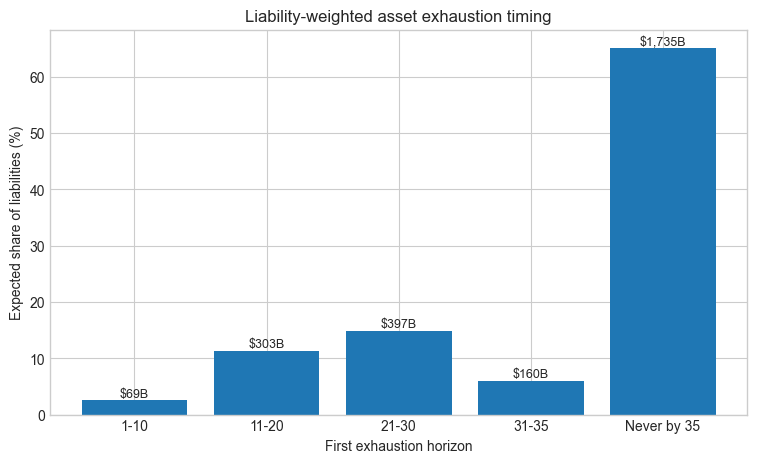

In [9]:
liability_bins = liability_weighted_exhaustion_bins(results, plan_metrics)
display(liability_bins.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(liability_bins["bin"].astype(str), liability_bins["liability_share"] * 100)
ax.set_title("Liability-weighted asset exhaustion timing")
ax.set_xlabel("First exhaustion horizon")
ax.set_ylabel("Expected share of liabilities (%)")
for bar, value in zip(bars, liability_bins["expected_liability_billion"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"${value:,.0f}B", ha="center", va="bottom", fontsize=9)
plt.show()

## Exhaustion-Year Distribution

The first figure shows the cumulative probability that assets are exhausted by each projection year: the liability-weighted curve across all plans, plus the individual curves for the highest-risk plans. The second figure shows each plan's full exhaustion CDF as small multiples of risk, sorted from highest to lowest 35-year exhaustion probability.

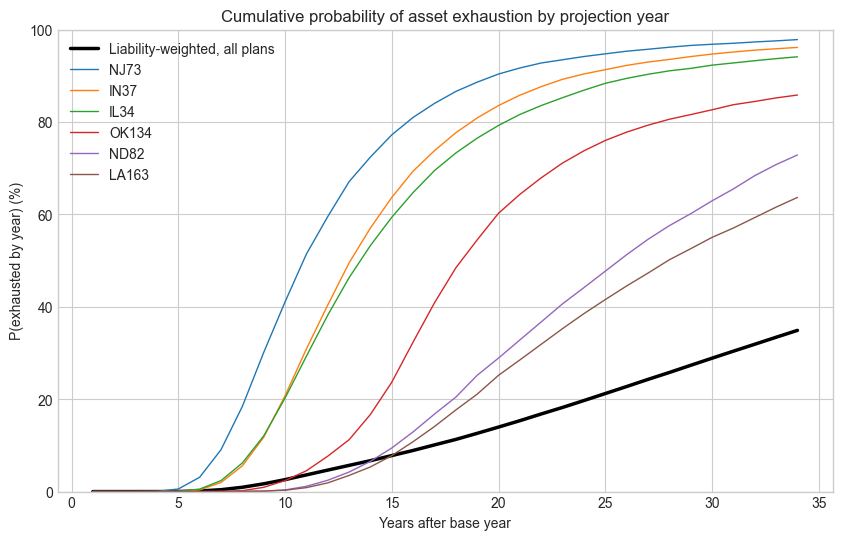

,by_year_5,by_year_10,by_year_15,by_year_20,by_year_25,by_year_30,by_year_34
NJ73,0.6,41.0,77.2,90.4,94.8,96.8,97.8
IN37,0.0,20.7,63.7,83.6,91.3,94.7,96.1
IL34,0.1,20.2,59.4,79.3,88.4,92.3,94.1
OK134,0.0,2.4,23.7,60.2,76.0,82.6,85.8
ND82,0.0,0.4,9.4,28.9,47.7,62.9,72.9
LA163,0.0,0.3,7.8,25.2,41.6,55.0,63.7
MO175,0.0,0.1,3.8,15.5,33.3,50.1,58.7
TX108,0.0,0.3,5.8,18.6,33.3,47.1,56.8
NM74,0.0,0.1,4.1,15.8,30.6,43.4,51.9
IL32,0.0,0.0,1.9,9.5,22.4,37.4,48.8


In [10]:
cdf_by_plan, cdf_weighted = exhaustion_cdf(results, plan_metrics, max_year=N_PROJ)

top_risk = exhaustion.nlargest(6, "prob_exhaust_35")["plan"].tolist()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cdf_weighted.index, cdf_weighted * 100, color="black", linewidth=2.5, label="Liability-weighted, all plans")
for plan in top_risk:
    ax.plot(cdf_by_plan.index, cdf_by_plan[plan] * 100, linewidth=1, label=plan)
ax.set_title("Cumulative probability of asset exhaustion by projection year")
ax.set_xlabel("Years after base year")
ax.set_ylabel("P(exhausted by year) (%)")
ax.set_ylim(0, 100)
ax.legend()
plt.show()

# Exhaustion CDF table at selected horizons (plan rows sorted by risk)
horizon_cols = [5, 10, 15, 20, 25, 30, N_PROJ]
cdf_table = (cdf_by_plan.loc[horizon_cols].T * 100).round(1)
cdf_table.columns = [f"by_year_{h}" for h in horizon_cols]
display(cdf_table.sort_values(f"by_year_{N_PROJ}", ascending=False))

## Plan-Level Exhaustion Probabilities And Insolvency Severity

The left panel shows each plan's cumulative probability of exhausting assets by 10, 20, and 35 years (nested bars — the CDF is monotone). The right panel shows `mean_years_insolvent`: the average number of projection years spent with zero assets per path, a severity measure that separates plans that exhaust early and stay insolvent from plans that barely cross the line. The full per-plan frame is available as `exhaustion` for custom queries.

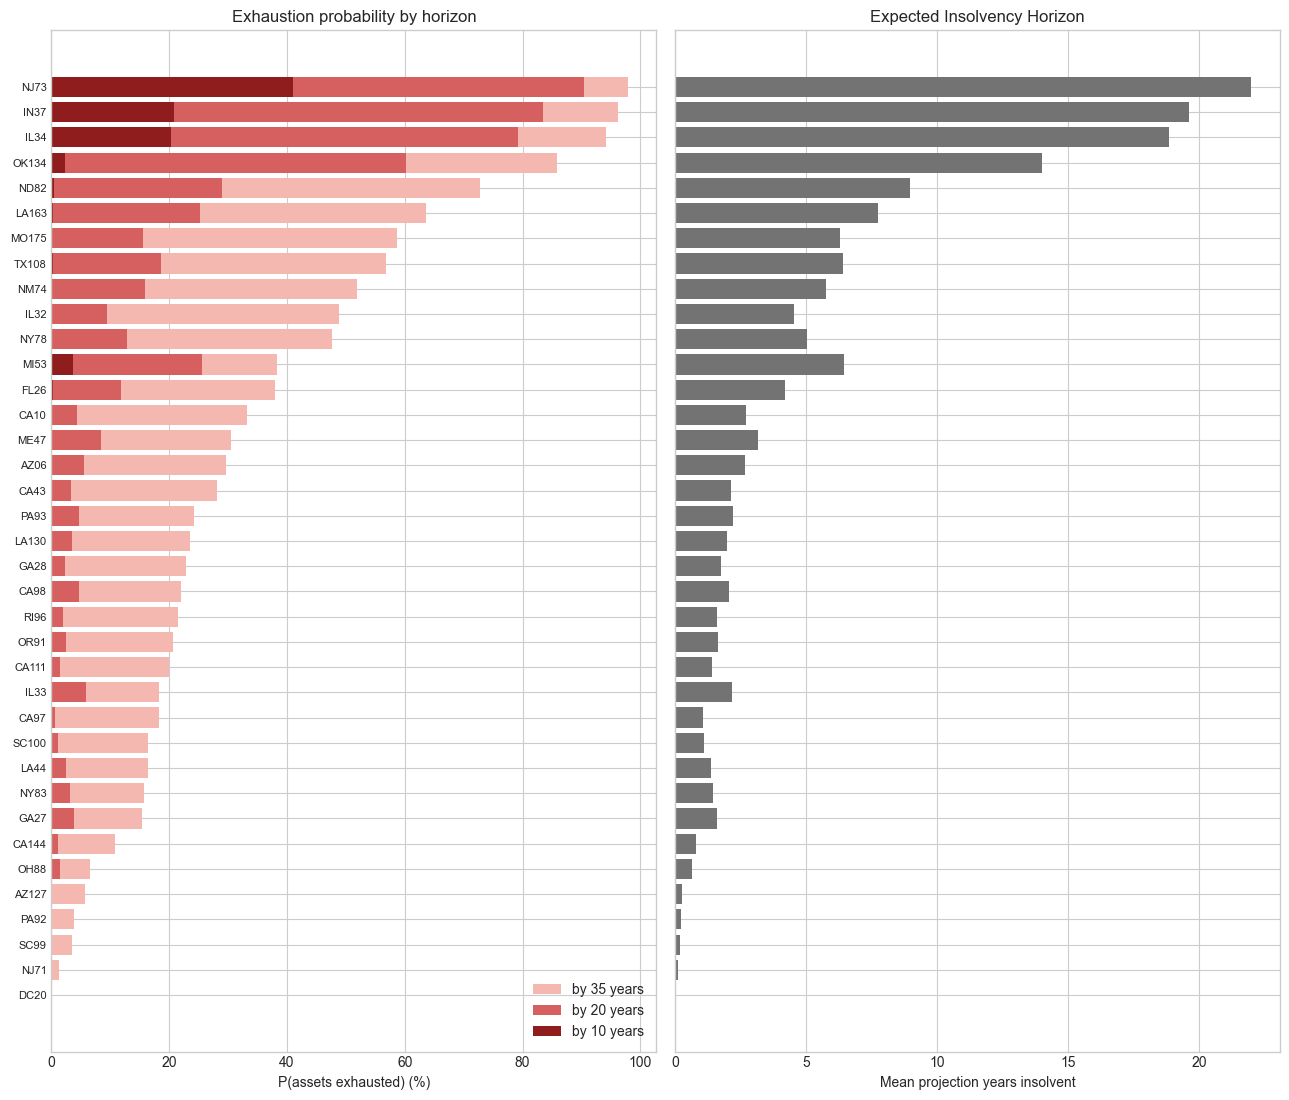

In [25]:
t = exhaustion.sort_values("prob_exhaust_35", ascending=True).reset_index(drop=True)
y = np.arange(len(t))

fig, axes = plt.subplots(1, 2, figsize=(13, max(6, len(t) * 0.30)), sharey=True)
ax = axes[0]
ax.barh(y, t["prob_exhaust_35"] * 100, color="#f4b8b0", label="by 35 years")
ax.barh(y, t["prob_exhaust_20"] * 100, color="#d65f5f", label="by 20 years")
ax.barh(y, t["prob_exhaust_10"] * 100, color="#8f1d1d", label="by 10 years")
ax.set_yticks(y)
ax.set_yticklabels(t["plan"], fontsize=8)
ax.set_xlabel("P(assets exhausted) (%)")
ax.set_title("Exhaustion probability by horizon")
ax.legend(loc="lower right")

ax = axes[1]
ax.barh(y, t["mean_years_insolvent"], color="0.45")
ax.set_xlabel("Mean projection years insolvent")
ax.set_title("Expected Insolvency Horizon")
plt.tight_layout()
plt.show()

## Probability Below Funding-Ratio Thresholds Over Time

The figure shows the cross-plan average probability that simulated funding ratios fall below selected thresholds in each projection year, over the full usable horizon. The probability of being *at or above* full funding in a year is one minus the `< 1.0` line.

,plan,year,threshold,probability
0,AZ06,2022,0.4,0.0000
1,AZ06,2022,0.6,0.0000
2,AZ06,2022,0.8,1.0000
3,AZ06,2022,1.0,1.0000
4,AZ06,2023,0.4,0.0093


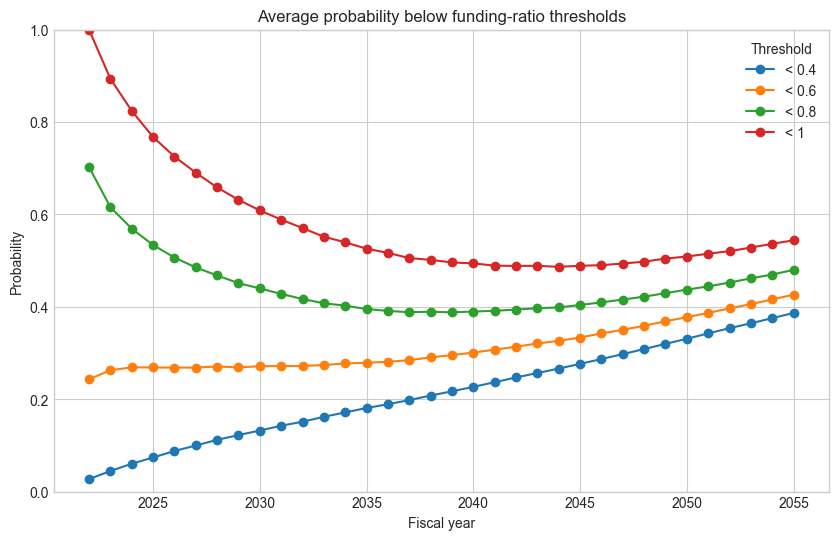

In [12]:
risk_over_time = ra.threshold_risk_over_time(results, thresholds=(0.4, 0.6, 0.8, 1.0), graph_years=N_PROJ)
display(risk_over_time.head())

fig, ax = ra.plot_threshold_risk(results, thresholds=(0.4, 0.6, 0.8, 1.0), graph_years=N_PROJ)
plt.show()

## Funding-Ratio Distribution At Selected Horizons

Each row shows a plan's simulated funding-ratio distribution — thin line 5-95 percentile, thick line 20-80 percentile, tick at the median — at the `GRAPH_YEARS` mark (left) and at the end of the usable projection (right), sorted by median. The x-axis is capped at 3 for readability; upper tails of well-funded plans extend beyond it. The pooled histogram below shows all plan-path funding ratios at the shorter horizon. Full per-plan stats (including `prob_depleted` and threshold probabilities) remain available as `terminal_short` / `terminal_long`.

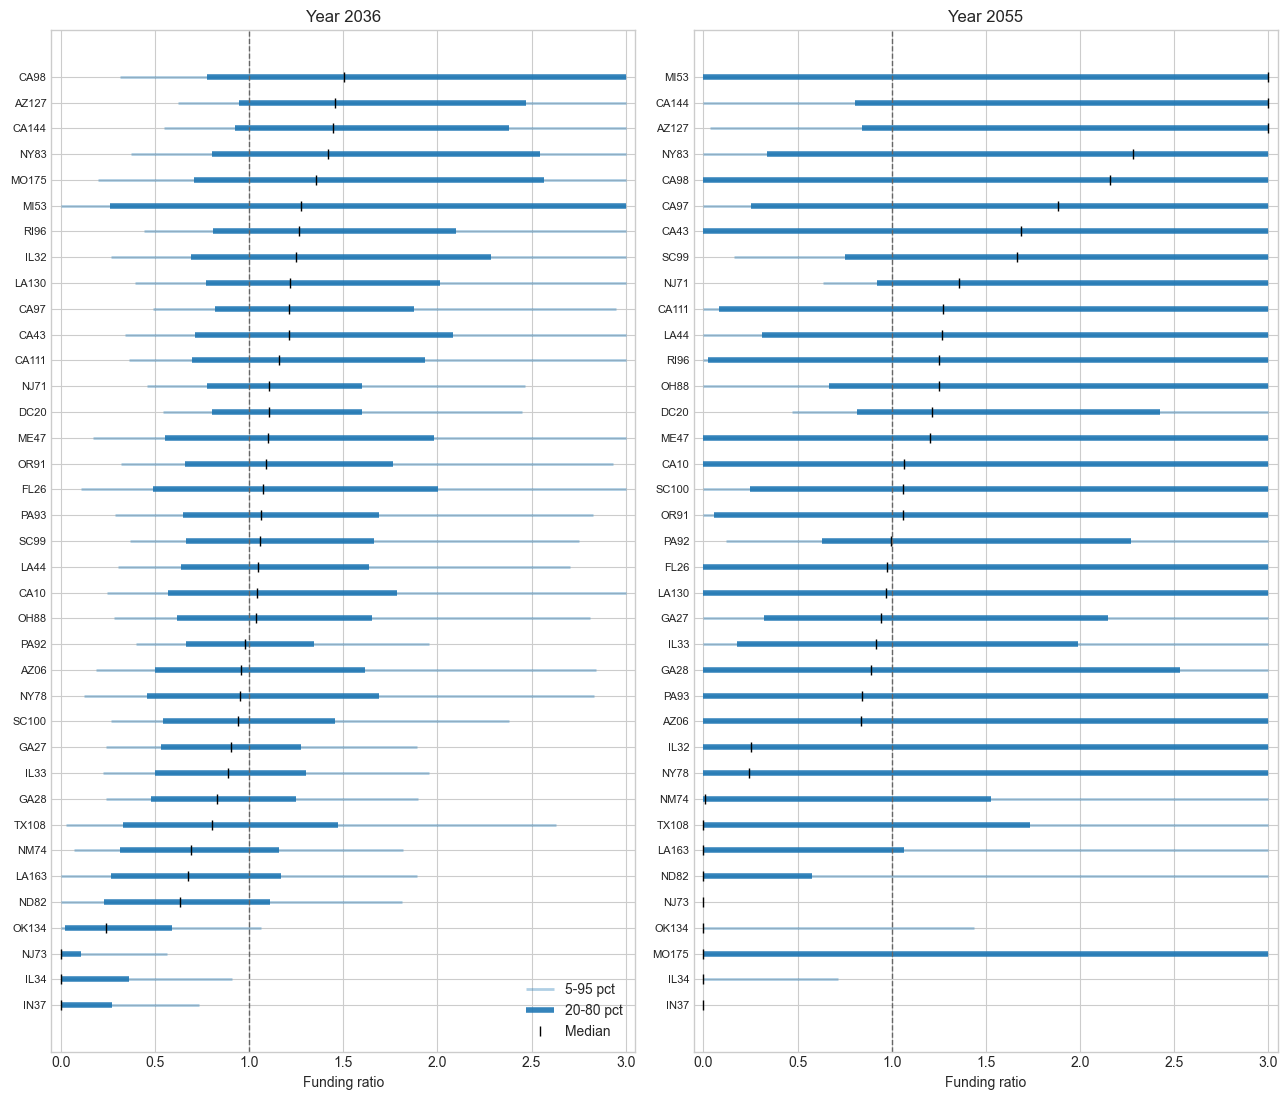

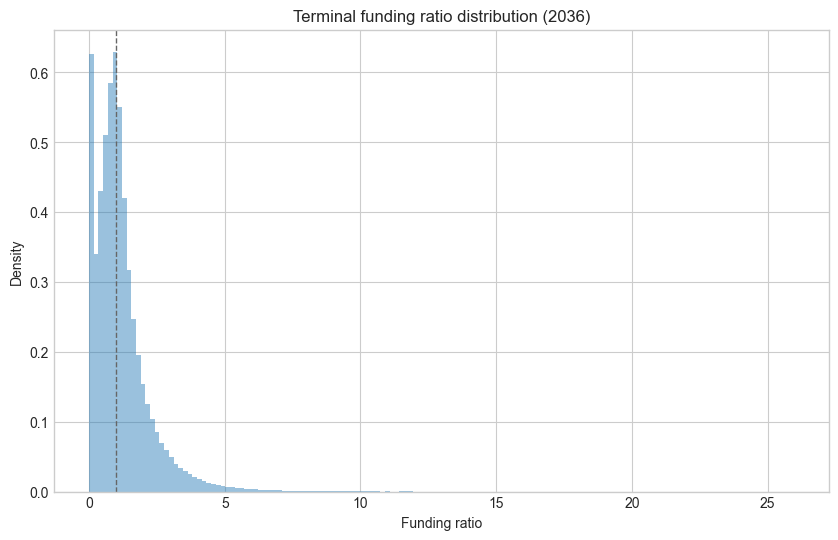

In [26]:
terminal_short = ra.terminal_risk_table(results, year_offset=GRAPH_YEARS - 1, thresholds=(0.4, 0.6, 0.8, 1.0))
terminal_long = ra.terminal_risk_table(results, year_offset=N_PROJ - 1, thresholds=(0.4, 0.6, 0.8, 1.0))


def plot_fr_intervals(table, title, ax, x_cap=3.0):
    t = table.sort_values("median").reset_index(drop=True)
    y = np.arange(len(t))
    ax.hlines(y, t["q05"].clip(upper=x_cap), t["q95"].clip(upper=x_cap),
              color="tab:blue", alpha=0.35, linewidth=2, label="5-95 pct")
    ax.hlines(y, t["q20"].clip(upper=x_cap), t["q80"].clip(upper=x_cap),
              color="tab:blue", alpha=0.9, linewidth=4, label="20-80 pct")
    ax.plot(t["median"].clip(upper=x_cap), y, "k|", markersize=7, label="Median")
    ax.axvline(1.0, color="0.4", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(t["plan"], fontsize=8)
    ax.set_xlim(-0.05, x_cap + 0.05)
    ax.set_xlabel("Funding ratio")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(13, max(6, len(terminal_short) * 0.30)))
plot_fr_intervals(terminal_short, f"Year {int(terminal_short['year'].iloc[0])}", axes[0])
plot_fr_intervals(terminal_long, f"Year {int(terminal_long['year'].iloc[0])}", axes[1])
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = ra.plot_terminal_distribution(results, year_offset=GRAPH_YEARS - 1)
plt.show()

## Distress-Probability Heatmap

Each cell is the probability that a plan's funding ratio is below 0.4 in that projection year — deep distress, near the point where exhaustion becomes hard to avoid. Plans are sorted by overall distress probability. (For a central-tendency view, the module's `ra.plot_plan_heatmap(results, statistic="q50")` is still available.)

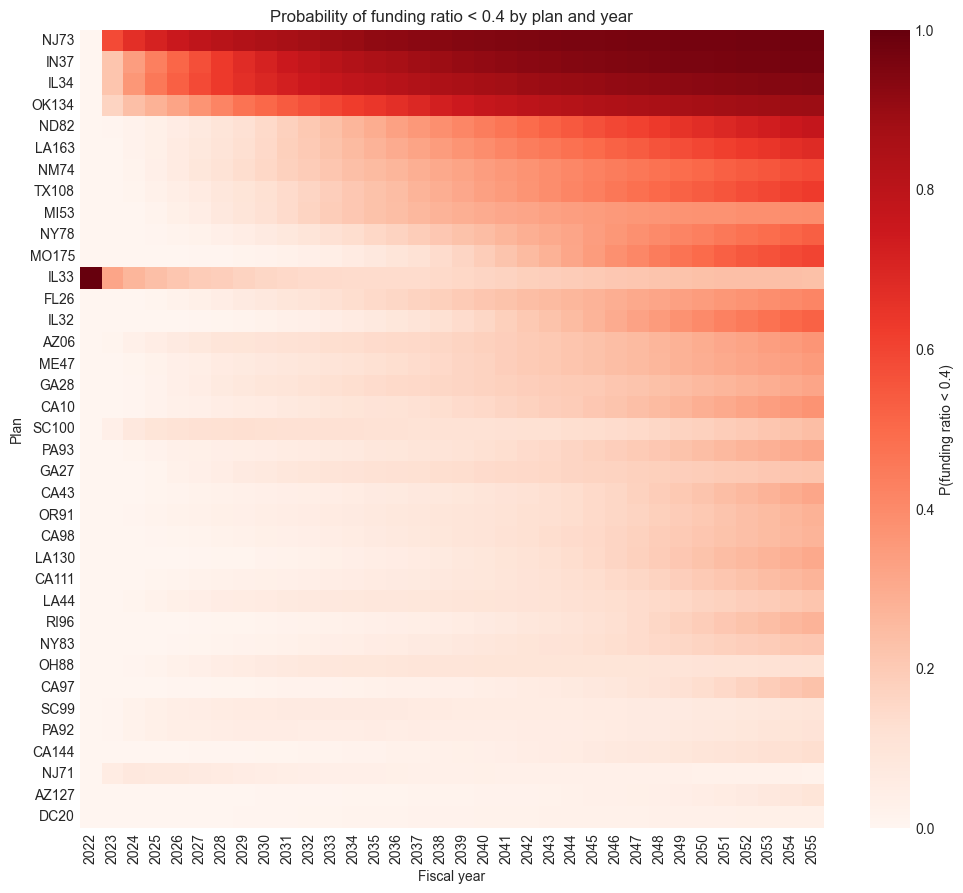

In [29]:
DISTRESS_THRESHOLD = 0.4
risk_full = ra.threshold_risk_over_time(results, thresholds=(DISTRESS_THRESHOLD,), graph_years=N_PROJ)
heat = risk_full.pivot_table(index="plan", columns="year", values="probability")
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, max(6, len(heat) * 0.28)))
sns.heatmap(heat, ax=ax, cmap="Reds", vmin=0, vmax=1,
            cbar_kws={"label": f"P(funding ratio < {DISTRESS_THRESHOLD})"})
ax.set_title(f"Probability of funding ratio < {DISTRESS_THRESHOLD} by plan and year")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Plan")
plt.show()

## Exhaustion Risk By Official Funded Ratio

Cross-sectional relationship between each plan's official funded ratio in the base year and its simulated probability of exhausting assets within 20 years. Bubble size is proportional to GASB liabilities. The fitted line is a simple linear regression used only as a visual summary.

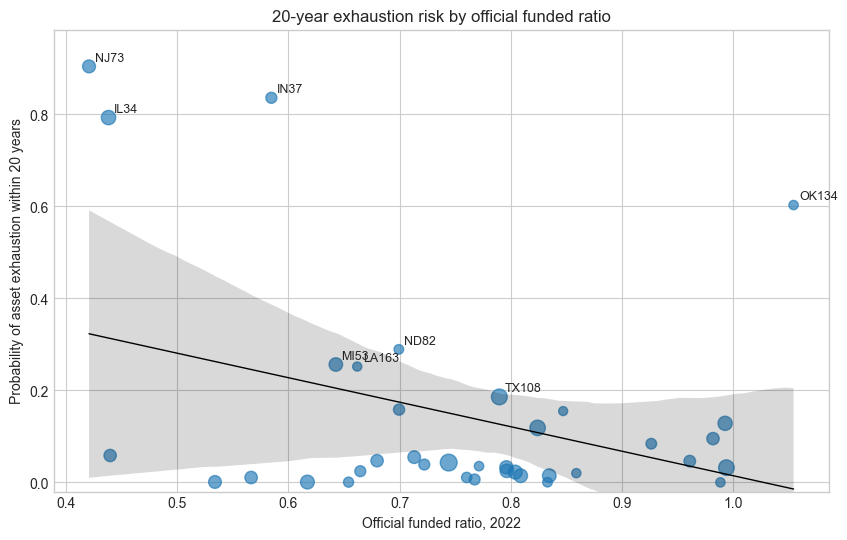

,plan,PlanName,official_funded_ratio,prob_exhaust_10,prob_exhaust_20,prob_exhaust_30,liability_billion,unfunded_liabilities_payroll,contribution_rate
24,NJ73,New Jersey Teachers,0.421,0.410,0.904,0.968,72.609,3.654,0.443
15,IN37,Indiana Teachers,0.585,0.207,0.836,0.947,22.214,2.054,0.393
14,IL34,Illinois Teachers,0.438,0.202,0.793,0.923,143.524,6.921,0.606
29,OK134,Oklahoma Police,1.054,0.024,0.602,0.826,2.929,-0.447,0.324
22,ND82,North Dakota Teachers,0.699,0.004,0.289,0.629,4.480,1.712,0.248
20,MI53,Michigan Public Schools,0.643,0.037,0.256,0.366,98.142,3.520,0.429
17,LA163,Baton Rouge City-Parish ERS,0.662,0.003,0.252,0.550,1.978,4.355,0.472
36,TX108,Texas Teachers,0.790,0.003,0.186,0.471,245.561,0.981,0.170
25,NM74,New Mexico PERA,0.700,0.001,0.158,0.434,23.924,2.922,0.295
21,MO175,Kansas City (MO) ERS,0.847,0.001,0.155,0.501,1.492,1.381,0.232


In [30]:
risk_scatter = exhaustion.merge(
    plan_metrics[["plan", "PlanName", "assets_liabilities", "liability_billion", "unfunded_liabilities_payroll", "contribution_rate"]],
    on="plan",
    suffixes=("", "_metric"),
)
plot_df = risk_scatter.dropna(subset=["official_funded_ratio", "prob_exhaust_20", "liability_billion"])
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 35 + 6 * np.sqrt(plot_df["liability_billion"].clip(lower=0))
ax.scatter(plot_df["official_funded_ratio"], plot_df["prob_exhaust_20"], s=sizes, alpha=0.65)
sns.regplot(data=plot_df, x="official_funded_ratio", y="prob_exhaust_20", scatter=False, ax=ax, color="black", line_kws={"linewidth": 1})
for _, row in plot_df.sort_values("prob_exhaust_20", ascending=False).head(8).iterrows():
    ax.annotate(row["plan"], (row["official_funded_ratio"], row["prob_exhaust_20"]), fontsize=9, xytext=(4, 4), textcoords="offset points")
ax.set_title("20-year exhaustion risk by official funded ratio")
ax.set_xlabel(f"Official funded ratio, {BASE_YEAR}")
ax.set_ylabel("Probability of asset exhaustion within 20 years")
ax.set_ylim(-0.02, min(1.02, max(0.1, plot_df["prob_exhaust_20"].max() + 0.08)))
plt.show()

display(plot_df[["plan", "PlanName", "official_funded_ratio", "prob_exhaust_10", "prob_exhaust_20", "prob_exhaust_30", "liability_billion", "unfunded_liabilities_payroll", "contribution_rate"]].sort_values("prob_exhaust_20", ascending=False).round(3))

## Exhaustion Risk By Contribution Rate

Relationship between each plan's current contribution rate (total pension contributions divided by payroll) and its simulated 20-year exhaustion probability. Descriptive, not causal: high contribution rates may reflect plan stress rather than preventing it.

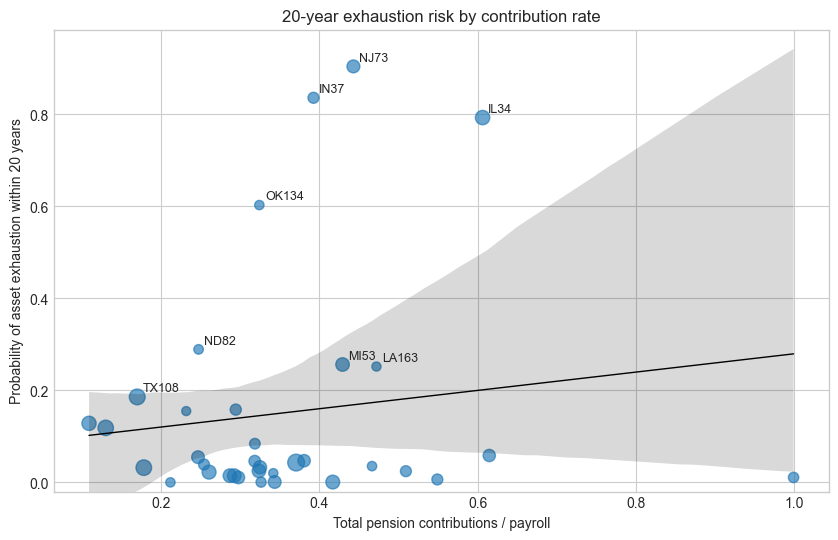

,plan,PlanName,contribution_rate,prob_exhaust_10,prob_exhaust_20,prob_exhaust_30,liability_billion,official_funded_ratio,unfunded_liabilities_payroll
24,NJ73,New Jersey Teachers,0.443,0.410,0.904,0.968,72.609,0.421,3.654
15,IN37,Indiana Teachers,0.393,0.207,0.836,0.947,22.214,0.585,2.054
14,IL34,Illinois Teachers,0.606,0.202,0.793,0.923,143.524,0.438,6.921
29,OK134,Oklahoma Police,0.324,0.024,0.602,0.826,2.929,1.054,-0.447
22,ND82,North Dakota Teachers,0.248,0.004,0.289,0.629,4.480,0.699,1.712
20,MI53,Michigan Public Schools,0.429,0.037,0.256,0.366,98.142,0.643,3.520
17,LA163,Baton Rouge City-Parish ERS,0.472,0.003,0.252,0.550,1.978,0.662,4.355
36,TX108,Texas Teachers,0.170,0.003,0.186,0.471,245.561,0.790,0.981
25,NM74,New Mexico PERA,0.295,0.001,0.158,0.434,23.924,0.700,2.922
21,MO175,Kansas City (MO) ERS,0.232,0.001,0.155,0.501,1.492,0.847,1.381


In [31]:
contribution_scatter = exhaustion.merge(
    plan_metrics[["plan", "PlanName", "official_funded_ratio", "liability_billion", "unfunded_liabilities_payroll", "contribution_rate"]],
    on="plan",
    suffixes=("", "_metric"),
)
plot_df = contribution_scatter.dropna(subset=["contribution_rate", "prob_exhaust_20", "liability_billion"])

fig, ax = plt.subplots(figsize=(10, 6))
sizes = 35 + 6 * np.sqrt(plot_df["liability_billion"].clip(lower=0))
ax.scatter(plot_df["contribution_rate"], plot_df["prob_exhaust_20"], s=sizes, alpha=0.65)
sns.regplot(data=plot_df, x="contribution_rate", y="prob_exhaust_20", scatter=False, ax=ax, color="black", line_kws={"linewidth": 1})
for _, row in plot_df.sort_values("prob_exhaust_20", ascending=False).head(8).iterrows():
    ax.annotate(row["plan"], (row["contribution_rate"], row["prob_exhaust_20"]), fontsize=9, xytext=(4, 4), textcoords="offset points")
ax.set_title("20-year exhaustion risk by contribution rate")
ax.set_xlabel("Total pension contributions / payroll")
ax.set_ylabel("Probability of asset exhaustion within 20 years")
ax.set_ylim(-0.02, min(1.02, max(0.1, plot_df["prob_exhaust_20"].max() + 0.08)))
plt.show()

display(
    plot_df[["plan", "PlanName", "contribution_rate", "prob_exhaust_10", "prob_exhaust_20", "prob_exhaust_30", "liability_billion", "official_funded_ratio", "unfunded_liabilities_payroll"]]
    .sort_values("prob_exhaust_20", ascending=False)
    .round(3)
)

---
# Part 2: Aggregate Dynamics

## Aggregate Funded Ratio And Unfunded Liability

Both figures aggregate simulated dollar balances across plans **within each Monte Carlo path** and then summarize across paths. Because all plans share common market shocks, these fans are genuine aggregate risk distributions: a bad path is bad for every plan at once. The first figure shows the aggregate funded ratio; the second the aggregate unfunded liability (AAL − assets) in dollars, which becomes negative when aggregate assets exceed aggregate liabilities. Years with nonpositive aggregate AAL (placeholder final year) are excluded.

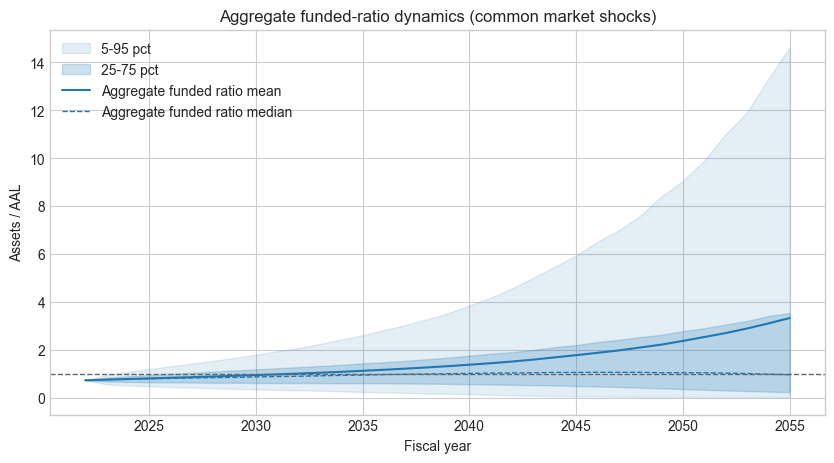

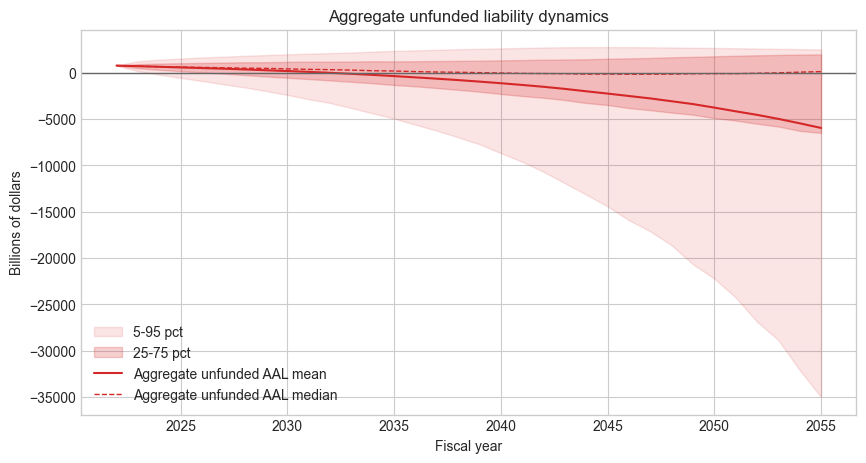

,year,mean,q05,q25,q50,q75,q95
0,2022,0.726,0.726,0.726,0.726,0.726,0.726
1,2023,0.753,0.563,0.675,0.754,0.832,0.942
2,2024,0.779,0.508,0.658,0.773,0.892,1.074
3,2025,0.806,0.475,0.647,0.790,0.945,1.197
4,2026,0.831,0.437,0.641,0.806,0.994,1.311
5,2027,0.857,0.416,0.632,0.822,1.038,1.426
6,2028,0.884,0.390,0.623,0.839,1.089,1.539
7,2029,0.915,0.368,0.624,0.848,1.138,1.662
8,2030,0.944,0.345,0.616,0.867,1.184,1.797
9,2031,0.973,0.326,0.609,0.884,1.228,1.945


In [32]:
ratio_paths = np.divide(agg_assets, agg_aal, out=np.full_like(agg_assets, np.nan), where=agg_aal > 0)
ratio_fan = fan_table(agg_years, ratio_paths)
unfunded_fan = fan_table(agg_years, (agg_aal - agg_assets) / 1_000_000_000)

fig, ax = plt.subplots(figsize=(10, 5))
plot_fan(ax, ratio_fan, "Aggregate funded ratio")
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Aggregate funded-ratio dynamics (common market shocks)")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Assets / AAL")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_fan(ax, unfunded_fan, "Aggregate unfunded AAL", color="tab:red")
ax.axhline(0.0, color="0.4", linewidth=1)
ax.set_title("Aggregate unfunded liability dynamics")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Billions of dollars")
ax.legend()
plt.show()

display(ratio_fan.head(10).round(3))

## Average Funding-Ratio Forecast

The black line is the historical equal-weighted average of official funded ratios across the plans in the run. The fan is the simulated continuation: the **equal-weighted average funding ratio across plans, computed within each Monte Carlo path** and then summarized across paths. Per-path cross-plan averaging is valid because all plans share common market shocks. This equal-plan view describes the typical plan and complements the dollar-aggregate fan above, which is dominated by the largest plans.

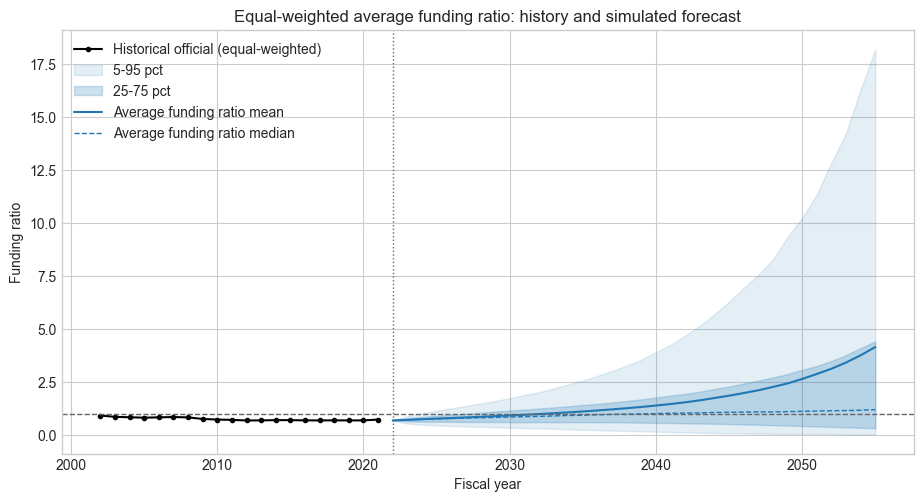

,year,mean,q05,q25,q50,q75,q95
0,2022,0.708,0.708,0.708,0.708,0.708,0.708
1,2023,0.739,0.559,0.665,0.740,0.814,0.919
2,2024,0.768,0.510,0.654,0.762,0.876,1.048
3,2025,0.797,0.482,0.647,0.783,0.931,1.171
4,2026,0.825,0.447,0.644,0.801,0.979,1.281
5,2027,0.852,0.430,0.639,0.820,1.025,1.394
6,2028,0.880,0.405,0.633,0.838,1.077,1.506
7,2029,0.913,0.386,0.636,0.851,1.129,1.626
8,2030,0.943,0.367,0.629,0.870,1.176,1.763
9,2031,0.975,0.349,0.626,0.888,1.222,1.911


In [33]:
# Equal-weighted average funding ratio per path (cross-plan average, valid under common shocks)
n_sims_common = min(r.n_simulations for r in results.values())
fr_stack = np.stack([
    r.funding_ratio().iloc[:N_PROJ, :n_sims_common].to_numpy(dtype="float64")
    for r in results.values()
], axis=0)
avg_fr_paths = np.nanmean(fr_stack, axis=0)
fr_years = np.asarray(next(iter(results.values())).years(N_PROJ))
avg_fr_fan = fan_table(fr_years, avg_fr_paths)

hist = historical_official_funding(ppd, plan_metrics["ppid"].dropna().astype(int).tolist())
hist = hist.loc[hist["fy"].between(2002, BASE_YEAR)]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(hist["fy"], hist["equal_weighted"], color="black", marker="o", markersize=3,
        label="Historical official (equal-weighted)")
plot_fan(ax, avg_fr_fan, "Average funding ratio")
ax.axvline(BASE_YEAR, color="0.4", linestyle=":", linewidth=1)
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Equal-weighted average funding ratio: history and simulated forecast")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Funding ratio")
ax.legend()
plt.show()

display(avg_fr_fan.head(10).round(3))

## GDP-Normalized Aggregate Burden

This section normalizes the aggregate balance sheet by nominal GDP. Observed nominal GDP from the official FRED API is used only through the model base year; afterwards GDP grows at a model-consistent nominal rate (average model inflation compounded with the 1 percent population-growth assumption). This is a deterministic scaling denominator, not a macro forecast, so all dispersion in the fan comes from the simulated numerator.

The section requires `FRED_API_KEY` (notebook variable or environment variable); without it, it prints a skip message and the rest of the notebook still runs.

,item,value
0,Base GDP year,2022.000000
1,"Base nominal GDP, billions",26054.614250
2,Average model inflation,0.025062
3,Projected nominal GDP growth,0.035313


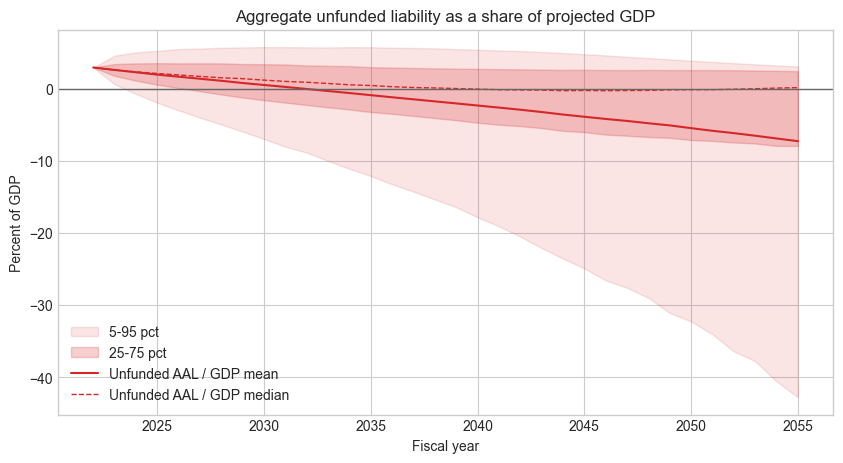

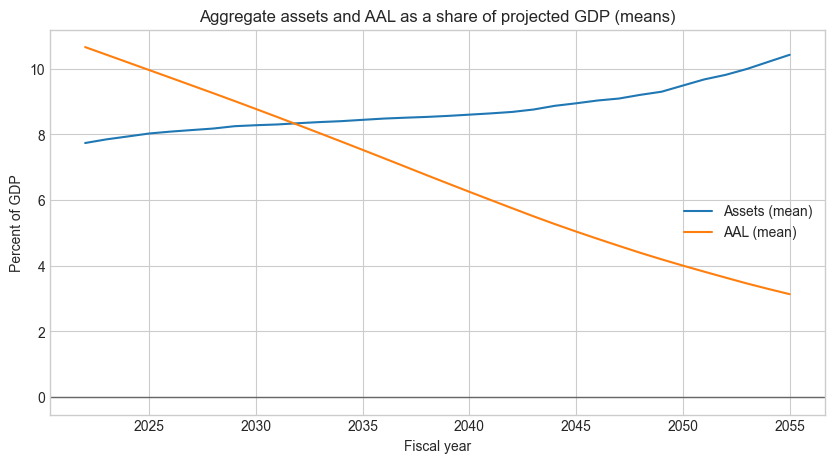

,year,mean,q05,q25,q50,q75,q95
29,2051,-5.854,-34.028,-7.251,-0.155,2.554,3.690
30,2052,-6.174,-36.408,-7.470,-0.091,2.534,3.523
31,2053,-6.532,-37.764,-7.612,-0.029,2.497,3.360
32,2054,-6.914,-40.566,-7.939,0.064,2.458,3.204
33,2055,-7.288,-42.742,-7.945,0.130,2.402,3.056


In [34]:
gdp_series = try_fetch_fred("GDP")

if gdp_series is None:
    print("GDP normalization skipped (no FRED data). Set FRED_API_KEY and rerun this cell.")
else:
    gdp_series["year"] = gdp_series["date"].dt.year
    gdp_annual = gdp_series.groupby("year", as_index=False)["GDP"].mean()
    gdp_observed = gdp_annual.loc[gdp_annual["year"] <= BASE_YEAR]
    base_row = gdp_observed.loc[gdp_observed["year"] == BASE_YEAR]
    if base_row.empty:
        base_row = gdp_observed.tail(1)
    base_gdp_billion = float(base_row["GDP"].iloc[-1])
    base_gdp_year = int(base_row["year"].iloc[-1])

    model_inflation = float(np.nanmean([float(r.scalars.get("Inflation", np.nan)) for r in results.values()]))
    model_nominal_gdp_growth = (1 + model_inflation) * (1 + MODEL_POPULATION_GROWTH) - 1

    gdp_path = base_gdp_billion * (1 + model_nominal_gdp_growth) ** (agg_years.astype(float) - base_gdp_year)

    display(pd.DataFrame([
        {"item": "Base GDP year", "value": base_gdp_year},
        {"item": "Base nominal GDP, billions", "value": base_gdp_billion},
        {"item": "Average model inflation", "value": model_inflation},
        {"item": "Projected nominal GDP growth", "value": model_nominal_gdp_growth},
    ]))

    unfunded_pct_paths = 100 * (agg_aal - agg_assets) / 1_000_000_000 / gdp_path[:, None]
    unfunded_pct_fan = fan_table(agg_years, unfunded_pct_paths)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_fan(ax, unfunded_pct_fan, "Unfunded AAL / GDP", color="tab:red")
    ax.axhline(0.0, color="0.4", linewidth=1)
    ax.set_title("Aggregate unfunded liability as a share of projected GDP")
    ax.set_xlabel("Fiscal year")
    ax.set_ylabel("Percent of GDP")
    ax.legend()
    plt.show()

    assets_pct_mean = 100 * np.nanmean(agg_assets, axis=1) / 1_000_000_000 / gdp_path
    aal_pct_mean = 100 * np.nanmean(agg_aal, axis=1) / 1_000_000_000 / gdp_path
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(agg_years, assets_pct_mean, label="Assets (mean)")
    ax.plot(agg_years, aal_pct_mean, label="AAL (mean)")
    ax.axhline(0, color="0.4", linewidth=1)
    ax.set_title("Aggregate assets and AAL as a share of projected GDP (means)")
    ax.set_xlabel("Fiscal year")
    ax.set_ylabel("Percent of GDP")
    ax.legend()
    plt.show()

    display(unfunded_pct_fan.tail(5).round(3))

---
# Part 3: Per-Plan Detail

## Single-Plan Forecast And Cash Flows

Select one plan: historical official funded ratios (black) followed by the simulated funding-ratio fan over the full usable projection, then mean projected cash inflows and outflows. Change `PLAN` to inspect a different plan.

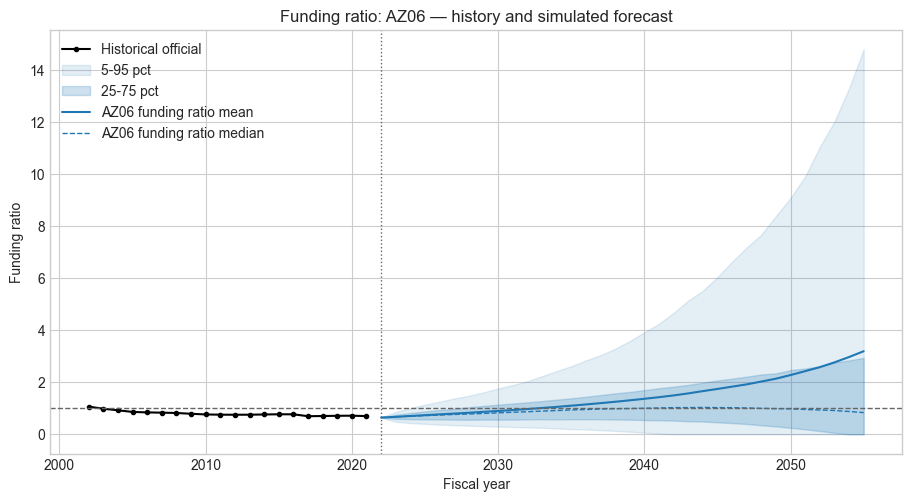

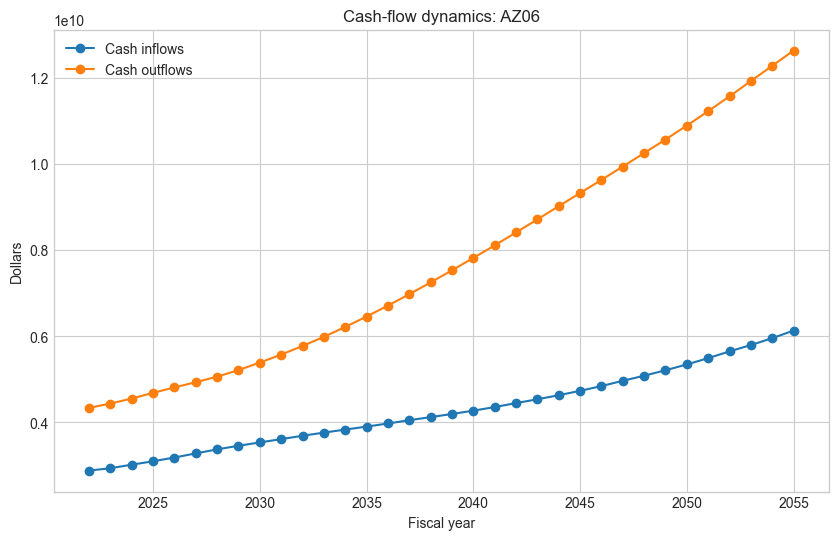

,year,mean,q05,q25,q50,q75,q95
0,2022,0.643,0.643,0.643,0.643,0.643,0.643
1,2023,0.673,0.483,0.595,0.674,0.752,0.862
2,2024,0.704,0.432,0.581,0.697,0.819,1.006
3,2025,0.737,0.404,0.573,0.719,0.880,1.139
4,2026,0.768,0.370,0.571,0.741,0.936,1.256
5,2027,0.798,0.352,0.566,0.763,0.985,1.377
6,2028,0.829,0.331,0.562,0.782,1.040,1.482
7,2029,0.865,0.314,0.567,0.801,1.092,1.611
8,2030,0.898,0.298,0.565,0.826,1.138,1.763
9,2031,0.933,0.282,0.566,0.848,1.184,1.892


In [35]:
PLAN = next(iter(results))
# PLAN = "CA10"

result = results[PLAN]
plan_fr = result.funding_ratio().iloc[:N_PROJ].to_numpy(dtype="float64")
plan_fan = fan_table(np.asarray(result.years(N_PROJ)), plan_fr)

fig, ax = plt.subplots(figsize=(11, 5.5))
actual = ra.actual_funding_ratio(ppd, result.ppid)
if not actual.empty:
    a = actual.loc[actual["fy"].between(2002, BASE_YEAR)]
    ax.plot(a["fy"], a["funding_ratio"], color="black", marker="o", markersize=3,
            label="Historical official")
plot_fan(ax, plan_fan, f"{PLAN} funding ratio")
ax.axvline(BASE_YEAR, color="0.4", linestyle=":", linewidth=1)
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title(f"Funding ratio: {PLAN} — history and simulated forecast")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Funding ratio")
ax.legend()
plt.show()

fig, ax = ra.plot_cashflow_dynamics(result, graph_years=N_PROJ)
plt.show()

display(plan_fan.head(10).round(3))

## Largest Plans: Funding-Ratio Fans

Funding-ratio forecast fans for the five largest plans by GASB liability (mean line, 5-95 percentile band). These plans dominate the dollar aggregates in Part 2.

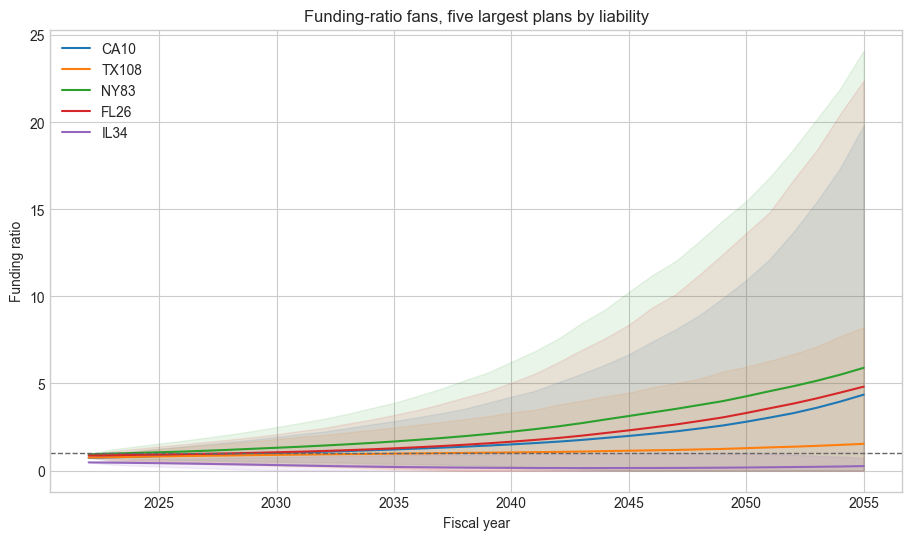

In [36]:
top_plans = plan_metrics.nlargest(5, "liability_billion")["plan"].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
for plan in top_plans:
    s = ra.forecast_summary(results[plan], graph_years=N_PROJ)
    line, = ax.plot(s["year"], s["mean"], label=plan)
    ax.fill_between(s["year"], s["q05"], s["q95"], alpha=0.10, color=line.get_color())
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Funding-ratio fans, five largest plans by liability")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Funding ratio")
ax.legend()
plt.show()

## Long-Form Simulation Export (Utility)

Converts simulated funding ratios into long format — one row per plan-year-simulation path — for downstream custom analysis. This is a data export helper, not a figure.

In [37]:
funding_long = ra.long_funding_ratios(results, graph_years=N_PROJ)
display(funding_long.head())
print(funding_long.shape)

,year,simulation,funding_ratio,plan
0,2022,0,0.643166,AZ06
1,2023,0,0.557015,AZ06
2,2024,0,0.531698,AZ06
3,2025,0,0.621658,AZ06
4,2026,0,0.546155,AZ06


(12580000, 4)


---
# Part 4: Baseline Characteristics, Alternative Discounting, And Validation

## Summary Statistics

Baseline characteristics of the modeled plans using the GASB/PPD inputs saved with the result files — starting-condition measures, not simulated outcomes. `unweighted_mean` gives every plan equal weight; `weighted_mean` uses the natural denominator of each ratio (liabilities, payroll, retired members, active members). Ratios are computed only when the denominator is positive and finite. The second table shows the same core fields plan by plan, sorted from lowest to highest official funded ratio; dollar amounts in billions.

In [38]:
baseline_summary = table1_summary(plan_metrics)
display(baseline_summary.round(3))

core_plan_table = plan_metrics[[
    "plan", "PlanName", "official_funded_ratio", "unfunded_liabilities_payroll",
    "total_pension_contributions_payroll", "active_retired_members",
    "liability_billion", "unfunded_liability_billion", "n_simulations"
]].sort_values("official_funded_ratio")
display(core_plan_table.round(3))

,metric,unweighted_mean,unweighted_sd,unweighted_obs,weighted_mean,weighted_sd,weighted_obs
0,Assets / liabilities,0.753,0.160,37,0.756,0.158,37
1,Unfunded liabilities / payroll,2.216,1.674,35,1.818,1.454,35
2,Total pension contributions / payroll,0.357,0.165,35,0.283,0.130,35
3,Active members / retired members,1.137,0.295,37,1.211,0.344,37
4,"Projected active member growth, 30 years",0.348,0.000,37,0.348,0.000,37


,plan,PlanName,official_funded_ratio,unfunded_liabilities_payroll,total_pension_contributions_payroll,active_retired_members,liability_billion,unfunded_liability_billion,n_simulations
24,NJ73,New Jersey Teachers,0.421,3.654,0.443,1.419,72.609,42.054,10000
14,IL34,Illinois Teachers,0.438,6.921,0.606,1.240,143.524,80.613,10000
13,IL33,Illinois SERS,0.440,6.065,0.615,0.792,52.050,29.157,10000
23,NJ71,New Jersey PERS,0.534,2.632,0.344,1.262,67.502,31.453,10000
34,SC100,South Carolina RS,0.567,2.486,0.298,1.332,56.924,24.674,10000
15,IN37,Indiana Teachers,0.585,2.054,0.393,1.075,22.214,9.224,10000
31,PA92,Pennsylvania School Employees,0.617,2.981,0.417,1.004,114.477,43.830,10000
20,MI53,Michigan Public Schools,0.643,3.520,0.429,0.689,98.142,35.067,10000
35,SC99,South Carolina Police,0.654,2.192,0.326,1.277,9.093,3.145,10000
17,LA163,Baton Rouge City-Parish ERS,0.662,4.355,0.472,0.739,1.978,0.669,10000


## Historical Official Funded Ratios

Historical official GASB funded ratios for the plans in the selected run: equal-weighted and liability-weighted by fiscal year. These are official accounting funded ratios, not AAA-discounted ratios.

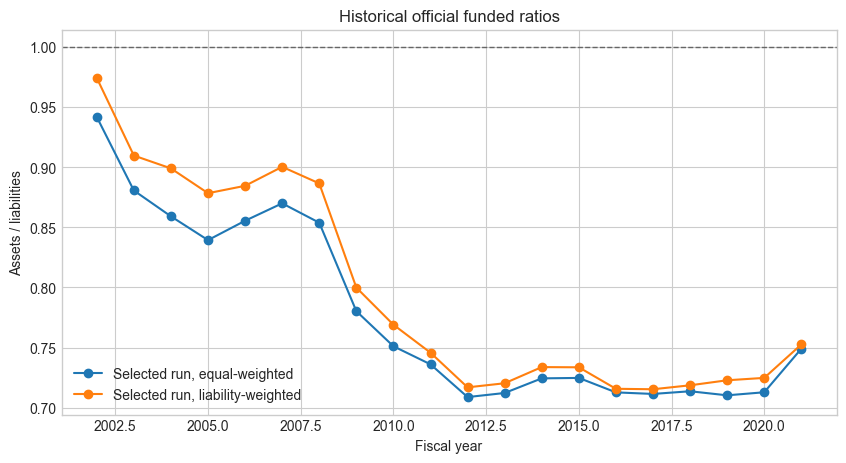

,fy,equal_weighted,liability_weighted,observations,weighted_observations
112,2012.0,0.709,0.717,37,37
113,2013.0,0.712,0.720,37,37
114,2014.0,0.724,0.734,37,37
115,2015.0,0.725,0.734,37,37
116,2016.0,0.713,0.716,37,37
117,2017.0,0.711,0.715,37,37
118,2018.0,0.714,0.719,37,37
119,2019.0,0.710,0.723,37,37
120,2020.0,0.713,0.725,37,37
121,2021.0,0.749,0.753,31,31


In [39]:
official_history = historical_official_funding(ppd, plan_metrics["ppid"].dropna().astype(int).tolist())
fig, ax = plt.subplots(figsize=(10, 5))
plot_history = official_history.loc[official_history["fy"].between(2002, 2023)]
ax.plot(plot_history["fy"], plot_history["equal_weighted"], marker="o", label="Selected run, equal-weighted")
ax.plot(plot_history["fy"], plot_history["liability_weighted"], marker="o", label="Selected run, liability-weighted")
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Historical official funded ratios")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Assets / liabilities")
ax.legend()
plt.show()

display(plot_history.tail(10).round(3))

## AAA-Discounted Cash-Flow PV Funded Ratios

Discounts the projected benefit cash-outflow vectors saved in the deterministic result files at the base-year average AAA corporate bond yield from FRED. This is an exploratory cash-flow PV, not a full AAA actuarial accrued liability revaluation. Requires `FRED_API_KEY`; skips gracefully without it.

AAA rate source: FRED AAA, calendar-year 2022 average; rate used = 4.074%


,measure,assets_billion,denominator_billion,funded_ratio
0,Official GASB funded ratio,2015.261,2664.402,0.756
1,Model AAL funded ratio,2015.261,2776.267,0.726
2,AAA cash-flow PV funded ratio,2015.261,4425.506,0.455


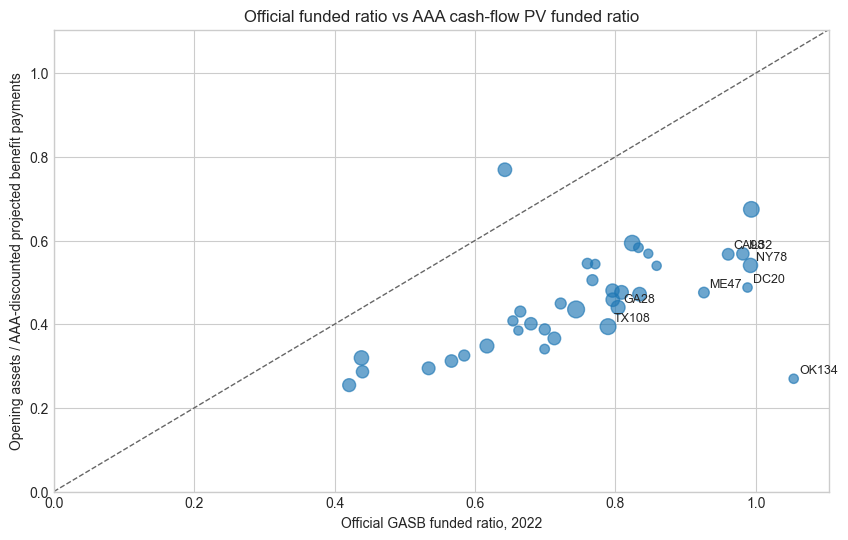

,plan,PlanName,official_funded_ratio,model_aal_funded_ratio,aaa_cashflow_pv_funded_ratio,opening_assets_billion,model_aal_billion,aaa_cashflow_pv_billion,plan_discount_rate
24,NJ73,New Jersey Teachers,0.421,0.406,0.254,30.555,75.284,120.122,0.070
29,OK134,Oklahoma Police,1.054,0.449,0.270,3.087,6.869,11.450,0.075
13,IL33,Illinois SERS,0.440,0.395,0.286,22.893,57.941,79.942,0.068
23,NJ71,New Jersey PERS,0.534,0.479,0.295,36.049,75.261,122.365,0.070
34,SC100,South Carolina RS,0.567,0.551,0.312,32.250,58.510,103.365,0.070
14,IL34,Illinois Teachers,0.438,0.470,0.319,62.910,133.873,196.938,0.070
15,IN37,Indiana Teachers,0.585,0.456,0.325,12.990,28.499,39.949,0.062
22,ND82,North Dakota Teachers,0.699,0.585,0.341,3.133,5.357,9.199,0.072
31,PA92,Pennsylvania School Employees,0.617,0.563,0.348,70.647,125.514,203.104,0.070
0,AZ06,Arizona SRS,0.713,0.643,0.366,45.589,70.883,124.556,0.070


In [40]:
aaa_series = try_fetch_fred("AAA")

if aaa_series is None:
    print("AAA section skipped (no FRED data). Set FRED_API_KEY and rerun this cell.")
    aaa_pv = None
else:
    def base_year_average_rate(series, series_id, base_year):
        in_base_year = series.loc[series["date"].dt.year == base_year, series_id].dropna()
        if not in_base_year.empty:
            return float(in_base_year.mean()) / 100, f"calendar-year {base_year} average"
        through = series.loc[series["date"] <= pd.Timestamp(base_year, 12, 31), ["date", series_id]].dropna()
        if through.empty:
            raise ValueError(f"No {series_id} observations are available through {base_year}.")
        last = through.iloc[-1]
        return float(last[series_id]) / 100, f"last observation through {base_year}: {last['date'].date()}"

    def present_value_cashflows(cashflows, annual_rate):
        cashflows = np.asarray(cashflows, dtype="float64")
        periods = np.arange(1, cashflows.size + 1, dtype="float64")
        valid = np.isfinite(cashflows) & (cashflows > 0)
        return float(np.sum(cashflows[valid] / ((1 + annual_rate) ** periods[valid])))

    def aaa_cashflow_pv_summary(results, plan_metrics, aaa_rate):
        metric_lookup = plan_metrics.set_index("plan")
        rows = []
        for plan, result in sorted(results.items()):
            cashflows = result.matrix("cash_outflows").iloc[:, 0].to_numpy(dtype="float64")
            base_assets = float(result.matrix("Assets").iloc[0, 0])
            model_aal = float(result.matrix("AAL").iloc[0, 0])
            plan_discount_rate = float(result.scalars.get("discountrate", np.nan))
            aaa_pv_value = present_value_cashflows(cashflows, aaa_rate)
            rows.append({
                "plan": plan,
                "PlanName": metric_lookup.loc[plan, "PlanName"] if plan in metric_lookup.index else np.nan,
                "official_funded_ratio": metric_lookup.loc[plan, "official_funded_ratio"] if plan in metric_lookup.index else np.nan,
                "official_liability_billion": metric_lookup.loc[plan, "liability_billion"] if plan in metric_lookup.index else np.nan,
                "opening_assets_billion": base_assets / 1_000_000_000,
                "model_aal_billion": model_aal / 1_000_000_000,
                "aaa_cashflow_pv_billion": aaa_pv_value / 1_000_000_000,
                "plan_discount_rate": plan_discount_rate,
                "model_aal_funded_ratio": base_assets / model_aal if model_aal > 0 else np.nan,
                "aaa_cashflow_pv_funded_ratio": base_assets / aaa_pv_value if aaa_pv_value > 0 else np.nan,
            })
        return pd.DataFrame(rows)

    aaa_rate, aaa_rate_basis = base_year_average_rate(aaa_series, "AAA", BASE_YEAR)
    aaa_pv = aaa_cashflow_pv_summary(results, plan_metrics, aaa_rate)

    aggregate_aaa = pd.DataFrame([
        {"measure": "Official GASB funded ratio",
         "assets_billion": num_col(plan_metrics, "ActAssets_GASB").sum() / 1_000_000,
         "denominator_billion": num_col(plan_metrics, "ActLiabilities_GASB").sum() / 1_000_000,
         "funded_ratio": num_col(plan_metrics, "ActAssets_GASB").sum() / num_col(plan_metrics, "ActLiabilities_GASB").sum()},
        {"measure": "Model AAL funded ratio",
         "assets_billion": aaa_pv["opening_assets_billion"].sum(),
         "denominator_billion": aaa_pv["model_aal_billion"].sum(),
         "funded_ratio": aaa_pv["opening_assets_billion"].sum() / aaa_pv["model_aal_billion"].sum()},
        {"measure": "AAA cash-flow PV funded ratio",
         "assets_billion": aaa_pv["opening_assets_billion"].sum(),
         "denominator_billion": aaa_pv["aaa_cashflow_pv_billion"].sum(),
         "funded_ratio": aaa_pv["opening_assets_billion"].sum() / aaa_pv["aaa_cashflow_pv_billion"].sum()},
    ])
    print(f"AAA rate source: FRED AAA, {aaa_rate_basis}; rate used = {aaa_rate:.3%}")
    display(aggregate_aaa.round(3))

    plot_df = aaa_pv.dropna(subset=["official_funded_ratio", "aaa_cashflow_pv_funded_ratio", "official_liability_billion"])
    fig, ax = plt.subplots(figsize=(10, 6))
    sizes = 35 + 6 * np.sqrt(plot_df["official_liability_billion"].clip(lower=0))
    ax.scatter(plot_df["official_funded_ratio"], plot_df["aaa_cashflow_pv_funded_ratio"], s=sizes, alpha=0.65)
    limit = max(plot_df["official_funded_ratio"].max(), plot_df["aaa_cashflow_pv_funded_ratio"].max()) + 0.05
    ax.plot([0, limit], [0, limit], color="0.4", linestyle="--", linewidth=1)
    for _, row in plot_df.assign(gap=lambda x: x["official_funded_ratio"] - x["aaa_cashflow_pv_funded_ratio"]).sort_values("gap", ascending=False).head(8).iterrows():
        ax.annotate(row["plan"], (row["official_funded_ratio"], row["aaa_cashflow_pv_funded_ratio"]), fontsize=9, xytext=(4, 4), textcoords="offset points")
    ax.set_title("Official funded ratio vs AAA cash-flow PV funded ratio")
    ax.set_xlabel(f"Official GASB funded ratio, {BASE_YEAR}")
    ax.set_ylabel("Opening assets / AAA-discounted projected benefit payments")
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    plt.show()

    display(
        aaa_pv[["plan", "PlanName", "official_funded_ratio", "model_aal_funded_ratio",
                "aaa_cashflow_pv_funded_ratio", "opening_assets_billion", "model_aal_billion",
                "aaa_cashflow_pv_billion", "plan_discount_rate"]]
        .sort_values("aaa_cashflow_pv_funded_ratio")
        .round(3)
    )

## Model Liability Validation Against CAFR AAL

Compares the model's saved AAL estimate with the official CAFR/GASB AAL recorded in the result file. Points far from the 45-degree line indicate plans where the model liability differs materially from the reported liability. The histogram shows the percent-difference diagnostic across plans.

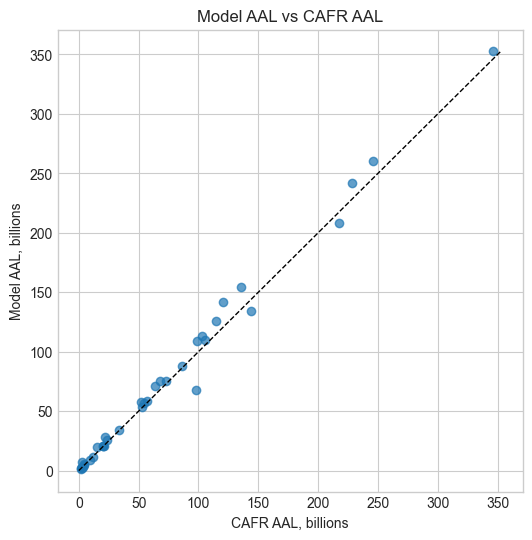

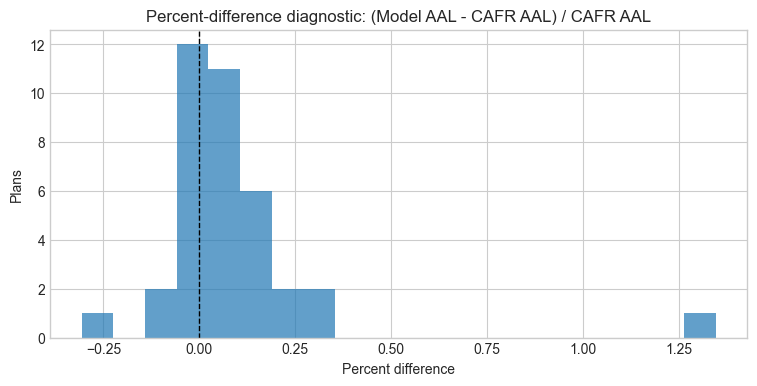

,plan,PlanName,model_aal_billion,cafr_aal_billion,percent_difference
20,MI53,Michigan Public Schools,68.038,98.142,-0.307
14,IL34,Illinois Teachers,133.873,143.524,-0.067
1,AZ127,Arizona State Corrections Officers,4.288,4.594,-0.066
16,LA130,Louisiana Municipal Police,3.283,3.449,-0.048
9,FL26,Florida RS,208.501,217.434,-0.041
21,MO175,Kansas City (MO) ERS,1.439,1.492,-0.036
33,RI96,Rhode Island Municipal,2.241,2.290,-0.021
18,LA44,Louisiana SERS,20.476,20.798,-0.016
4,CA144,San Diego City ERS,11.681,11.848,-0.014
7,CA98,San Francisco City & County,33.715,33.592,0.004


In [41]:
validation = plan_metrics.dropna(subset=["model_aal_billion", "cafr_aal_billion"])[["plan", "PlanName", "model_aal_billion", "cafr_aal_billion", "percent_difference"]].copy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(validation["cafr_aal_billion"], validation["model_aal_billion"], alpha=0.7)
limit = max(validation["cafr_aal_billion"].max(), validation["model_aal_billion"].max())
ax.plot([0, limit], [0, limit], color="black", linestyle="--", linewidth=1)
ax.set_title("Model AAL vs CAFR AAL")
ax.set_xlabel("CAFR AAL, billions")
ax.set_ylabel("Model AAL, billions")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation["percent_difference"].dropna(), bins=20, alpha=0.7)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Percent-difference diagnostic: (Model AAL - CAFR AAL) / CAFR AAL")
ax.set_xlabel("Percent difference")
ax.set_ylabel("Plans")
plt.show()

display(validation.sort_values("percent_difference").round(3))

---
# Items Requiring New Scenario Runs

The current result files support everything above. The following require new simulation scenarios, not more post-processing:

- **Contribution-policy counterfactuals:** the permanent contribution increase needed to hit target exhaustion probabilities (for example 0.5%, 1%, 3%) requires rerunning the asset stage with an explicit contribution-policy parameter. At `num_sim = 10000` the probability grid (0.01 percentage points) is fine enough; the missing piece is the policy lever in the simulation, not precision.
- **Waiting-period stabilization scenarios:** permanent contribution increases starting immediately versus after 5, 10, or 15 years — same policy engine as above, plus a start-delay parameter.
- **Investment-strategy counterfactuals:** reruns under alternative asset allocations or return assumptions (for example de-risking paths). The shared market-shock matrix makes these directly comparable path-by-path: the same market history can be replayed under each policy.
- **Model-consistent AAA liability revaluation:** recomputing AAL with an AAA discount rate inside the liability model (not just discounting projected cash flows, as in the exploratory section above).
- **Tier-level reform comparison (planned rework):** the earlier descriptive reform section was removed; the replacement should compare each plan's pre-change versus post-change tier provisions directly (matched to the model's tier structure), rather than the earliest-vs-latest workbook diff used before.
- **No-reform counterfactuals:** rerunning the liability model with pre-reform benefit rules for plans that changed tiers after 2007, to quantify what reforms saved.

Check the run manifest at the top before using tables as final results; rerun any missing plan outputs first.